# ZOMATO DATA ANALYSIS PROJECT

Zomato has an average of 17.5 million monthly transacting customers for its food delivery business. Average monthly active food delivery restaurant partners on Zomato's platform have also increased by 8.7% year-on-year, from 208,000 to 226,000.You are
working in a data-driven role at Zomato. You have a dataset of customers. As a data professional, you need to analyze the data, perform EDA (Exploratory Data Analysis) and visualization, and answer the following questions:

1) What type of restaurant do the majority of customers order from?
2) How many votes has each type of restaurant received from customers?
3) What are the ratings that the majority of restaurants have received?
4) Zomato has observed that most couples order most of their food online. What is their
   average spending on each order?
5) Which mode (online or offline) has received the maximum rating?
6) Which type of restaurant received more offline orders, so that Zomato can provide those
   customers with some good offers?

## STEP-1: IMPORTING LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

- pandas is used for data manipulation and analysis
- numpy is used for numerical operations
- matplotlib.pyplot and seaborn are used for visualization

## STEP-2: CREATE THE DATAFRAME

In [7]:
df = pd.read_csv("Zomato data .csv")
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


## STEP-3:Lets change the value of rate to actual float value

In [12]:
def handleRating(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

df['rate']= df['rate'].apply(handleRating)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [10]:
df.info()  #check for any null value in the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


## STEP-4: PLOT THE BAR GRPAH FOR VISUALISATION AND ANSWER TO 1ST QUESTION

C:\Users\mdmoz\AppData\Local\Temp\ipykernel_40208\3991907743.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['listed_in(type)'], palette = 'inferno_r')


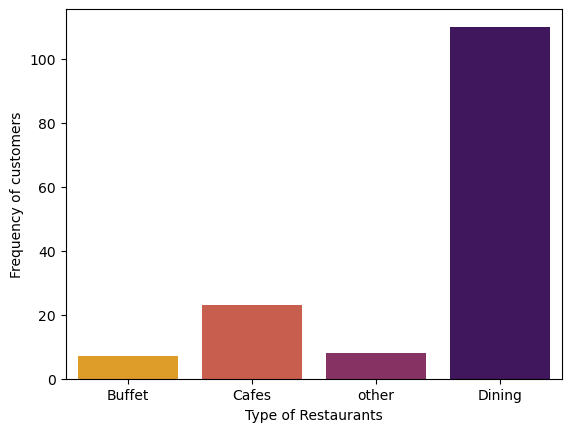

In [30]:

#generate the barplot using seaborn sns and show it
sns.countplot(x=df['listed_in(type)'], palette = 'inferno_r')
plt.xlabel("Type of Restaurants")
plt.ylabel("Frequency of customers")
plt.show()

## Q1. What type of restaurant do the majority of customers order from?
### Ans: Majority of the customers order from "Dining" type of restaurants

In [36]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


## STEP-5: PROGRAM TO ANSWER QUESTION 2ND

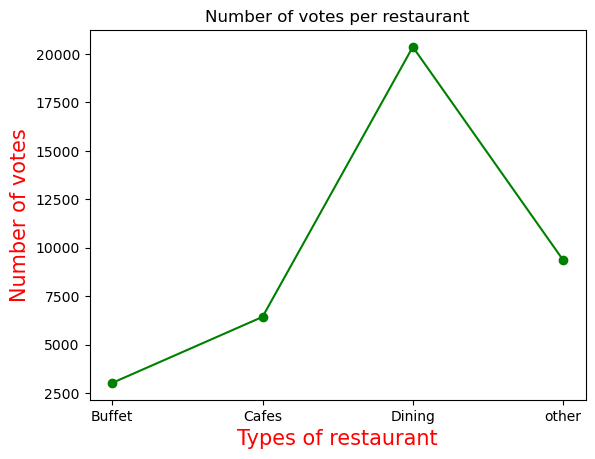

In [66]:
grouped_data = df.groupby("listed_in(type)")["votes"].sum()
result = pd.DataFrame({"votes":grouped_data})
plt.plot(result, color = 'green',marker = "o")
plt.xlabel("Types of restaurant", color = "red", size = 15)
plt.ylabel("Number of votes", color = "red", size = 15)
plt.title("Number of votes per restaurant")
plt.show()

### Q2. How many votes has each type of restaurant received from customers?
### ans: 
- 2500< buffet < 3000
- 5000< cafes < 6000
- Dining > 20000
- 9000 < Other < 10000 

### STEP-6: ANSWER TO 3RD QUESTION

In [76]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),type,vote,types
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,Buffet,775,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,Buffet,787,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,Buffet,918,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,Buffet,88,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet,Buffet,166,Buffet


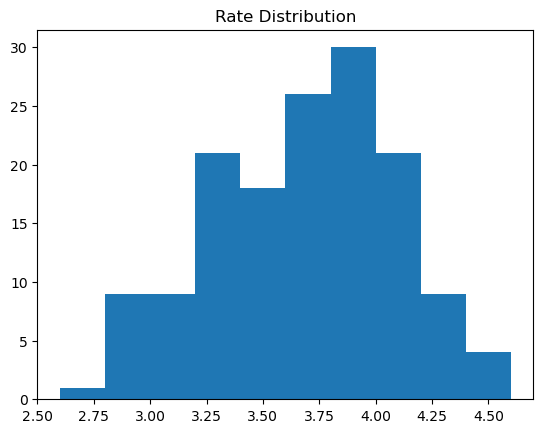

In [80]:
plt.hist(df['rate'], bins = 10)
plt.title("Rate Distribution")
plt.show()

### Q3. What are the ratings that the majority of restaurants have received?
### ans:
- Majority of the restaurants recieved rating of 3.75 to 4.00 out of 5

## AVERAGE ORDER SPENT BY COUPLES - ANSWER TO QUESTION NO 4

In [85]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),type,vote,types
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,Buffet,775,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,Buffet,787,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,Buffet,918,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,Buffet,88,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet,Buffet,166,Buffet


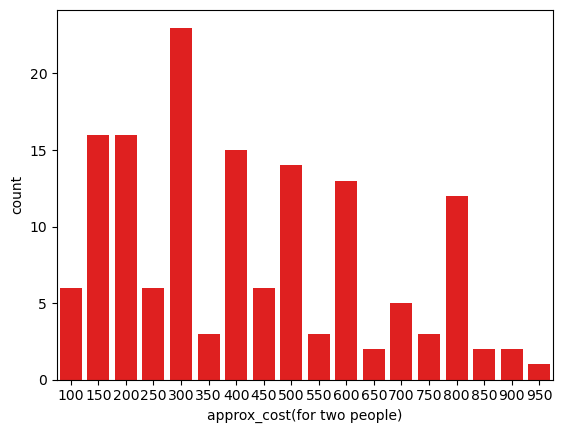

In [127]:
couple_data = df['approx_cost(for two people)']
#print(couple_data)
sns.countplot(x=couple_data, color = 'red')
plt.show()

## Q4. Zomato has observed that most couples order most of their food online. What is their average spending on each order?
- ans: Maximum of  Rs 300 spend on each other

# Which modes  recieves more ratings?

In [102]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),type,vote,types
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,Buffet,775,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,Buffet,787,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,Buffet,918,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,Buffet,88,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet,Buffet,166,Buffet


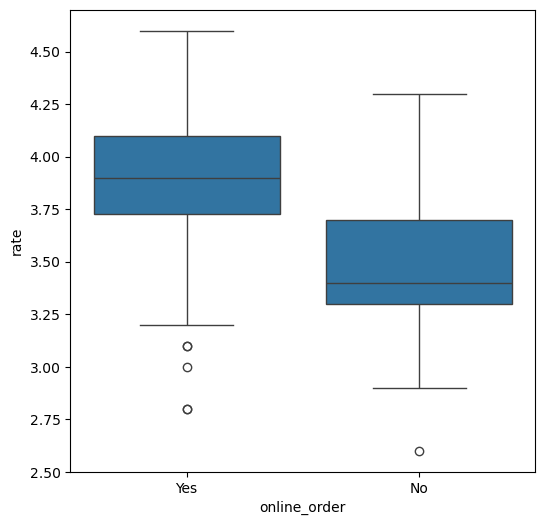

In [110]:
fig = plt.figure(figsize= (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)
plt.show()

## Which mode (online or offline) has received the maximum rating?
- Ans: Online order has recieved maximum ratings

## Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?

In [119]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),type,vote,types
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,Buffet,775,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,Buffet,787,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,Buffet,918,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,Buffet,88,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet,Buffet,166,Buffet


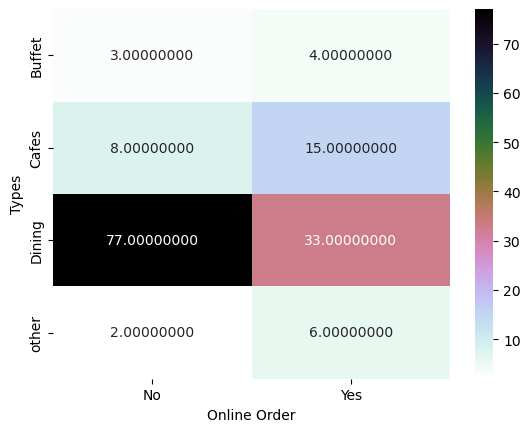

In [159]:
pivot_table = df.pivot_table(index = 'listed_in(type)', columns = 'online_order', aggfunc = 'size', fill_value = 0)
sns. heatmap(pivot_table, annot = True, cmap = 'cubehelix_r', fmt = '0.8f')
plt.xlabel("Online Order")
plt.ylabel("Types")
plt.show()

## Q6. Ans: Dinning types of restaurant gets more offline orders from customers